<a href="https://colab.research.google.com/github/fabriciothiengo/REATORES/blob/main/semibatelada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**REAÇÃO EM SEMIBATELADA**
---

Seja a reação em fase líquida $A + B \rightarrow C$ em um reator tanque operando em batelada, no qual B é adicionado lentamente ao reagente A, isto é, uma operação em semibatelada.

O balanço de massa para cada componente será o seguinte:

$$\frac{dC_A}{dt} = r_A - \frac{v_0}{V}C_A$$

$$\frac{dC_B}{dt} = \frac{v_0}{V}(C_{B_0}-C_B)+r_B$$

Considerando a reação elementar, $r_A=r_B=-kC_AC_B$. Sendo $V=V_0+v_0t$, com $V_0$ = 2m$^3$, $v_0$ = 1m$^3$/h, k=3,2 m$^3$/mol/h e $C_{A_0}=C_{B_0}$ = 1M, como fica o perfil de concentração das espécies ao longo do tempo e o perfil de conversão? Qual o tempo necessário para conversão de 83%?



A conversão máxima de B é 0.55 e ocorre em 0.93 h


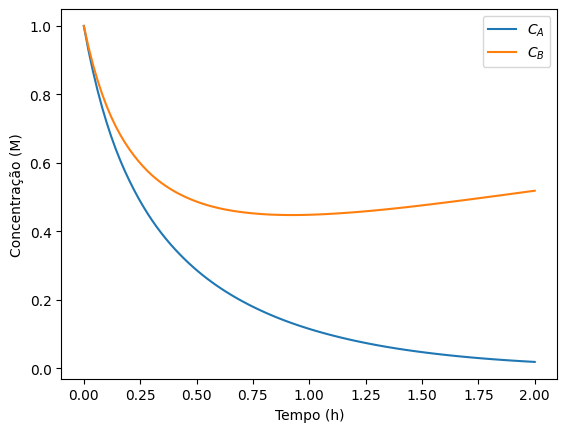

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

CA0=1
CB0=1

def eq(t,X):

  global CB0

  CA=X[0]
  CB=X[1]

  V0=2
  v0=1
  V=V0+v0*t
  k=3.2
  ra=-k*CA*CB
  rb=ra
  dCAdt=ra-(v0/V)*CA
  dCBdt=(v0/V)*(CB0-CB)+rb
  return [dCAdt,dCBdt]

tempo=2
sol=solve_ivp(eq,[0,tempo],[CA0,CB0],t_eval=np.linspace(0,tempo,100),method='RK45')

plt.plot(sol.t,sol.y[0],label='$C_A$')
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração (M)')
plt.legend()

plt.plot(sol.t,sol.y[1],label='$C_B$')
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração (M)')
plt.legend()

pos=np.argmin(sol.y[1])
CB_min=sol.y[1][pos]
X=(CB0-CB_min)/CB0
print(f'A conversão máxima de B é {X:.2f} e ocorre em {sol.t[pos]:.2f} h')

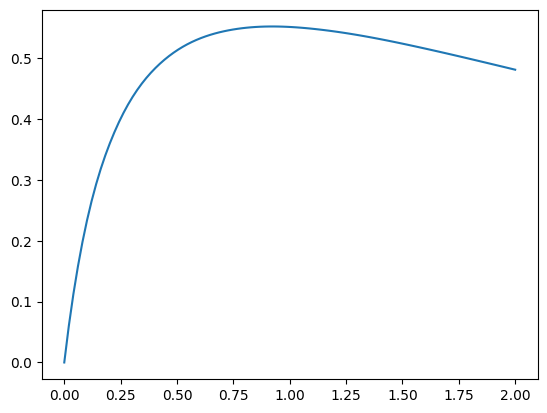

In [ ]:
XX=(CB0-sol.y[1])/CB0
plt.plot(sol.t,XX)